In [1]:
!pip install datasets transformers comet_ml --quiet
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from google.colab import userdata
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.3/782.3 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.1 MB/s eta 0:00:00


In [2]:
USE_COMET = True  # Set True if you want logging
if USE_COMET:
    from comet_ml import Experiment
    experiment = Experiment(userdata.get('COMET_KEY'))
else:
    experiment = None
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/irsotarriva/general/6f4e608b70dc42f69ddc6f9b98d80c43



In [3]:
ds = load_dataset("roneneldan/TinyStories")

# Combine splits if needed
full_texts = ds["train"]["text"]

# 90-10 split
split_idx = int(0.9 * len(full_texts))
train_texts = full_texts[:split_idx]
val_texts = full_texts[split_idx:]

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [4]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

MAX_LEN = 128

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
class TinyStoriesDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return int(len(self.texts))

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        return input_ids
BATCH_SIZE = 128

train_dataset = TinyStoriesDataset(train_texts)
val_dataset = TinyStoriesDataset(val_texts)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LowRankMatrix(nn.Module):
    """
    Represents D + U V^T
    D is positive diagonal
    """

    def __init__(self, dim, rank):
        super().__init__()
        self.dim = dim
        self.rank = rank

        self.log_diag = nn.Parameter(torch.zeros(dim))
        self.U = nn.Parameter(torch.randn(dim, rank) * 0.02)
        self.V = nn.Parameter(torch.randn(dim, rank) * 0.02)

    def diag(self):
        return torch.exp(self.log_diag)

    def forward(self, x):
        # (B, d)
        D = self.diag()
        Dx = D * x
        low_rank = x @ self.V @ self.U.T
        return Dx + low_rank

    def inverse_apply(self, x):
        """
        Apply (D + U V^T)^-1 x via Woodbury
        """
        D = self.diag()
        D_inv = 1.0 / D

        # D^{-1} x
        Dx = D_inv * x

        # Compute Woodbury correction
        # A^{-1} = D^{-1} - D^{-1} U (I + V^T D^{-1} U)^-1 V^T D^{-1}

        U = self.U
        V = self.V

        # D^{-1} U
        DU = D_inv.unsqueeze(1) * U

        # Middle term
        middle = torch.eye(self.rank, device=x.device) + V.T @ DU
        middle_inv = torch.inverse(middle)

        # Compute correction
        correction = Dx @ V @ middle_inv @ DU.T

        return Dx - correction

class OrthogonalBasis(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(dim, dim))

    def forward(self):
        # QR gives orthogonal Q
        Q, _ = torch.linalg.qr(self.weight)
        return Q


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LagrangianRNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, rank=32, dt=0.1):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.dt = dt

        # Learned orthogonal basis
        self.basis = OrthogonalBasis(hidden_dim)

        # Low-rank structured matrices
        self.M = LowRankMatrix(hidden_dim, rank)
        self.C = LowRankMatrix(hidden_dim, rank)
        self.K = LowRankMatrix(hidden_dim, rank)

        # Embedding and readout
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.readout = nn.Linear(hidden_dim, vocab_size)

        self.obs_projection = nn.Linear(hidden_dim, hidden_dim)

    def token_entropy_regularizer(self, logits):
        probs = F.softmax(logits, dim=-1)
        entropy = -(probs * torch.log(probs + 1e-9)).sum(dim=-1)
        return -entropy.mean()
    def forward(self, input_ids, h0=None, v0=None):
        B, T = input_ids.shape
        device = input_ids.device

        if h0 is None:
            h = torch.zeros(B, self.hidden_dim, device=device)
        else:
            h = h0

        if v0 is None:
            v = torch.zeros(B, self.hidden_dim, device=device)
        else:
            v = v0

        logits_seq = []
        Q = self.basis()

        for t in range(T):

            # Rotate to spectral space
            z = h @ Q
            vz = v @ Q

            # Prediction
            logits = self.readout(h)
            logits_seq.append(logits.unsqueeze(1))

            target_emb = self.embedding(input_ids[:, t])
            pred_probs = F.softmax(logits, dim=-1)
            pred_emb = pred_probs @ self.embedding.weight

            error = target_emb - pred_emb
            F_obs = self.obs_projection(error)

            # Rotate force
            Fz = F_obs @ Q

            # Physics update in spectral space
            accel = self.M.inverse_apply(
                Fz - self.C(vz) - self.K(z)
            )

            vz = vz + self.dt * accel
            z = z + self.dt * vz

            # Rotate back
            h = z @ Q.T
            v = vz @ Q.T

        logits_seq = torch.cat(logits_seq, dim=1)
        return logits_seq, h, v
    def forward_with_loss(self, input_ids, vocab_size, h0=None, v0=None):
        B, T = input_ids.shape
        device = input_ids.device

        if h0 is None:
            h = torch.zeros(B, self.hidden_dim, device=device)
        else:
            h = h0

        if v0 is None:
            v = torch.zeros(B, self.hidden_dim, device=device)
        else:
            v = v0

        Q = self.basis()
        ce_loss_sum = 0.0
        n_tokens = 0
        token_entropy_loss_sum = 0.0
        # iterate up to T-1 because we predict t+1 from t
        for t in range(T - 1):
            # rotate to spectral space
            z = h @ Q
            vz = v @ Q

            # prediction for token t -> t+1
            logits = self.readout(h)  # (B, vocab)
            target_next = input_ids[:, t + 1]  # (B,)

            ce_loss_sum = ce_loss_sum + F.cross_entropy(logits, target_next)
            token_entropy_loss_sum = token_entropy_loss_sum + self.token_entropy_regularizer(logits)
            n_tokens += B

            target_emb = self.embedding(input_ids[:, t])
            pred_probs = F.softmax(logits, dim=-1)
            pred_emb = pred_probs @ self.embedding.weight

            error = target_emb - pred_emb
            F_obs = self.obs_projection(error)

            Fz = F_obs @ Q
            accel = self.M.inverse_apply(Fz - self.C(vz) - self.K(z))

            vz = vz + self.dt * accel
            z = z + self.dt * vz

            h = z @ Q.T
            v = vz @ Q.T

        loss = (ce_loss_sum / n_tokens) + 0.01*(token_entropy_loss_sum / n_tokens)
        return loss, h, v

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LagrangianRNN(
    vocab_size=tokenizer.vocab_size,
    hidden_dim=256,
    dt=0.01,
).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4)
print(device)

cuda


In [9]:
# Checkpoint configuration
checkpoint_path = "checkpoint.pt"
start_epoch = 0

train_losses = []
val_losses = []
norm_history = []  # track average hidden state norm per training step
step_train_losses = []
# Resume from checkpoint if it exists
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    norm_history = checkpoint.get("norm_history", [])
    print(f"Resuming training from epoch {start_epoch+1}")

EPOCHS = 50
total_steps = EPOCHS * len(train_loader)
logStep = 0
vocab_size = tokenizer.vocab_size

if experiment:
    experiment.log_parameters({
        "hidden_dim": model.hidden_dim,
        "dt": model.dt,
        "batch_size": BATCH_SIZE,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "optimizer": "Adam",
        "lr": 3e-4,
    })

for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_state_norm_sum = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        batch = batch.to(device)

        scheduled_len = int(1 + (MAX_LEN - 2) * logStep / 30000)
        seq_len = max(2, min(MAX_LEN, scheduled_len))
        cropped_batch = batch[:, :seq_len]

        optimizer.zero_grad()
        loss, h, v = model.forward_with_loss(cropped_batch, vocab_size)

        # regularizers (if you want them to affect gradients, keep them in graph;
        # if memory is still tight, you can compute them on detached copies)

        state_norm = h.norm(dim=1).mean().item()
        norm_history.append(state_norm)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_state_norm_sum += state_norm
        if experiment:
            experiment.log_metric("train_loss", loss.item(), step=logStep)
            experiment.log_metric("state_norm", state_norm, step=logStep)
        logStep += 1
        step_train_losses.append(loss.item())

    avg_train_loss = epoch_loss / len(train_loader)
    avg_state_norm = epoch_state_norm_sum / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits_seq, h, v = model(batch)
            pred = logits_seq[:, :-1, :].reshape(-1, vocab_size)
            target = batch[:, 1:].reshape(-1)
            loss = F.cross_entropy(pred, target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Save checkpoint
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "norm_history": norm_history,
    }
    torch.save(checkpoint, checkpoint_path)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Avg State Norm: {avg_state_norm:.4f}")

    if experiment:
        experiment.log_metric("train_loss_epoch", avg_train_loss, step=epoch)
        experiment.log_metric("val_loss_epoch", avg_val_loss, step=epoch)
        experiment.log_metric("state_norm_epoch", avg_state_norm, step=epoch)
if experiment:
    experiment.end()

Resuming training from epoch 3


Epoch 3:  51%|█████     | 7622/14905 [45:14<43:13,  2.81it/s]  


KeyboardInterrupt: 

In [10]:
checkpoint = {
        "epoch": 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "norm_history": norm_history,
    }
torch.save(checkpoint, checkpoint_path)

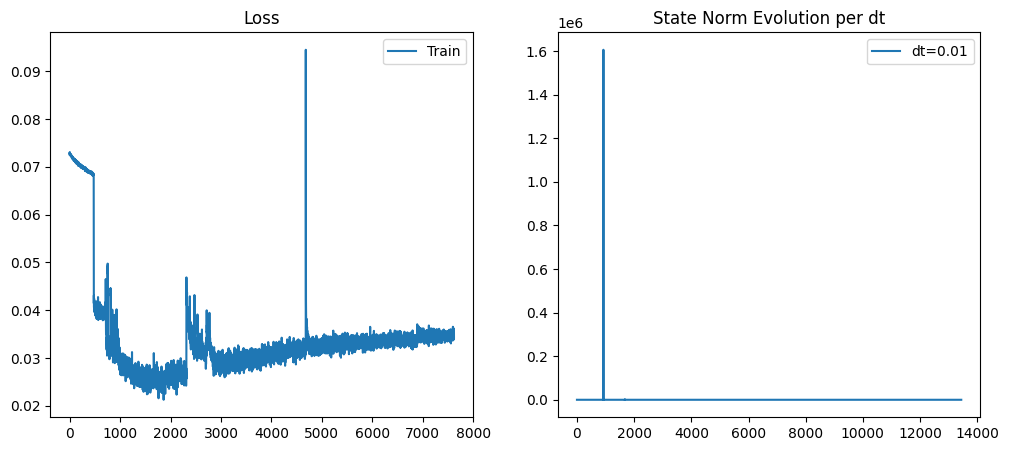

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(step_train_losses, label="Train")
#plt.plot(train_losses, label="Train")
#plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(norm_history, label=f"dt={model.dt}")
plt.title("State Norm Evolution per dt")
plt.legend()

plt.show()

In [12]:
import torch
import numpy as np

# Print original text, teacher forcing generation (true tokens as prefix),
# and free generation (model feeds its own predictions)
model.eval()
#idx = np.random.randint(len(val_dataset))
idx = 500
input_ids = train_dataset[idx].unsqueeze(0).to(device)  # (1, T)
#val_dataset[idx].unsqueeze(0).to(device)  # (1, T)
#crop to max len
max_len_generation = 100
input_ids = input_ids[:, :max_len_generation]
seq_len = input_ids.shape[1]

# Initialize sequences with the first (true) token
start_token_id = input_ids[0, 0].item()
forced_generated_ids = [start_token_id]
free_generated_ids = [start_token_id]

with torch.no_grad():
    for t in tqdm(range(1, seq_len), desc="Generating"):
        # Teacher forcing: feed the true prefix up to current position
        true_prefix = input_ids[:, :t]  # shape (1, t)
        logits_tf, h_tf, v_tf = model(true_prefix)
        next_logits_tf = logits_tf[:, -1, :]  # (1, vocab)
        next_id_tf = torch.argmax(next_logits_tf, dim=-1)  # (1,)
        forced_generated_ids.append(next_id_tf.item())

        # Free generation: feed the model its own previous predictions
        free_prefix = torch.tensor(
            free_generated_ids, dtype=torch.long, device=device
        ).unsqueeze(0)  # shape (1, t)
        logits_free, h_free, v_free = model(free_prefix)
        next_logits_free = logits_free[:, -1, :]
        next_id_free = torch.argmax(next_logits_free, dim=-1)
        free_generated_ids.append(next_id_free.item())

print("Original Text:")
print(tokenizer.decode(input_ids[0].cpu().numpy(), skip_special_tokens=True))
print("\nTeacher Forcing Generation:")
print(tokenizer.decode(forced_generated_ids, skip_special_tokens=True))
print("\nFree Generation:")
print(tokenizer.decode(free_generated_ids, skip_special_tokens=True))

Generating: 100%|██████████| 99/99 [00:12<00:00,  7.83it/s]

Original Text:
Once upon a time there was an intelligent frog. He lived in a big bathroom. The frog was very curious and he liked exploring.

One day, the frog was looking for something new to explore and he found a strange looking box. The box was filled with lots of shiny things. The frog was excited and he started playing with the shiny things.

The frog soon got tired of the shiny things and he decided to replace them with something else. He went around the bathroom looking for

Teacher Forcing Generation:
Once and a time, there was little girl named. loved to a,... loved a to, and.. to play. day to,
 a a,,,......

 One.



One,.......


..

.... The The




 The It The The The The The The The It The It It It It It The It It It It It

Free Generation:
Once and a time there was a, girl was a.. was a,. was a,. was a,, was a,.. a a,, was was,. was was,, he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he he h

In [ ]:
!pip install evaluate rouge_score nltk --quiet

  Preparing metadata (setup.py) ... done


In [ ]:
import evaluate
import nltk
from nltk.translate.bleu_score import sentence_bleu

model.eval()

rouge = evaluate.load("rouge")
bleu_scores = []
for idx in tqdm(range(int(len(val_dataset)/100)), desc="Evaluating"):
    input_ids = val_dataset[idx].unsqueeze(0).to(device)  # (1, T)
    seq_len = input_ids.shape[1]

    # Free generation: first token is true, then model feeds itself
    start_token_id = input_ids[0, 0].item()
    generated_ids = [start_token_id]

    with torch.no_grad():
        for t in range(1, seq_len):
            prefix = torch.tensor(
                generated_ids, dtype=torch.long, device=device
            ).unsqueeze(0)  # shape (1, t)
            logits_seq, h, v = model(prefix)
            next_logits = logits_seq[:, -1, :]  # (1, vocab)
            next_token = torch.argmax(next_logits, dim=-1)  # (1,)
            generated_ids.append(next_token.item())

    reference = tokenizer.decode(input_ids[0].cpu().numpy(), skip_special_tokens=True)
    candidate = tokenizer.decode(generated_ids, skip_special_tokens=True)
    # Compute BLEU score
    reference_tokens = reference.split()
    candidate_tokens = candidate.split()
    bleu_score = sentence_bleu([reference_tokens], candidate_tokens, weights=(0.5, 0.5))
    bleu_scores.append(bleu_score)
    # Update ROUGE
    rouge.add_batch(predictions=[candidate], references=[reference])
results = rouge.compute()
avg_bleu = np.mean(bleu_scores)
print(f"ROUGE Scores: {results}")
print(f"Average BLEU Score: {avg_bleu:.4f}")

Evaluating:  33%|███▎      | 69/211 [00:17<00:20,  7.00it/s]/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
Evaluating: 100%|██████████| 211/211 [00:33<00:00,  6.26it/s]


ROUGE Scores: {'rouge1': np.float64(0.2521255517141469), 'rouge2': np.float64(0.05271985196365973), 'rougeL': np.float64(0.1749629082101025), 'rougeLsum': np.float64(0.2215514221284764)}
Average BLEU Score: 0.0933
